In [1]:
from google.colab import files
uploaded=files.upload()

Saving final_table.xlsx to final_table.xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
file1_name, file2_name = list(uploaded.keys())[:2]

# Adjust sep='\t' if tab-separated, sep=',' if comma-separated
df1 = pd.read_csv(file1_name, sep='\t')  # Table 1
df2 = pd.read_csv(file2_name, sep='\t')  # Table 2

merged_df = pd.merge(df1, df2, on='id_patient', how='inner')

# Specify the exact column order
final_columns = [
    'id_patient',  # common ID
    'survival (weeks)',
    'age_at_t0 (years)',
    'who_performance_status',
    'gender',
    'height (cm)',
    'weight (kg)',
    'delay_t0_to_radiotherapy (weeks)',
    'dose (Gy)',
    'fractions_number'
]

# Reorder the merged dataframe
merged_df = merged_df[final_columns]

# Save as Excel
excel_filename = 'final_table.xlsx'
merged_df.to_excel(excel_filename, index=False)

# Download the Excel file
files.download(excel_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
df = pd.read_excel('final_table.xlsx')

In [ ]:
print(df['survival (weeks)'])

0       30
1       43
2       29
3       40
4       70
      ... 
259     45
260    104
261     34
262     41
263     56
Name: survival (weeks), Length: 264, dtype: int64


In [5]:
max_week = df['survival (weeks)'].max()
max_week

238

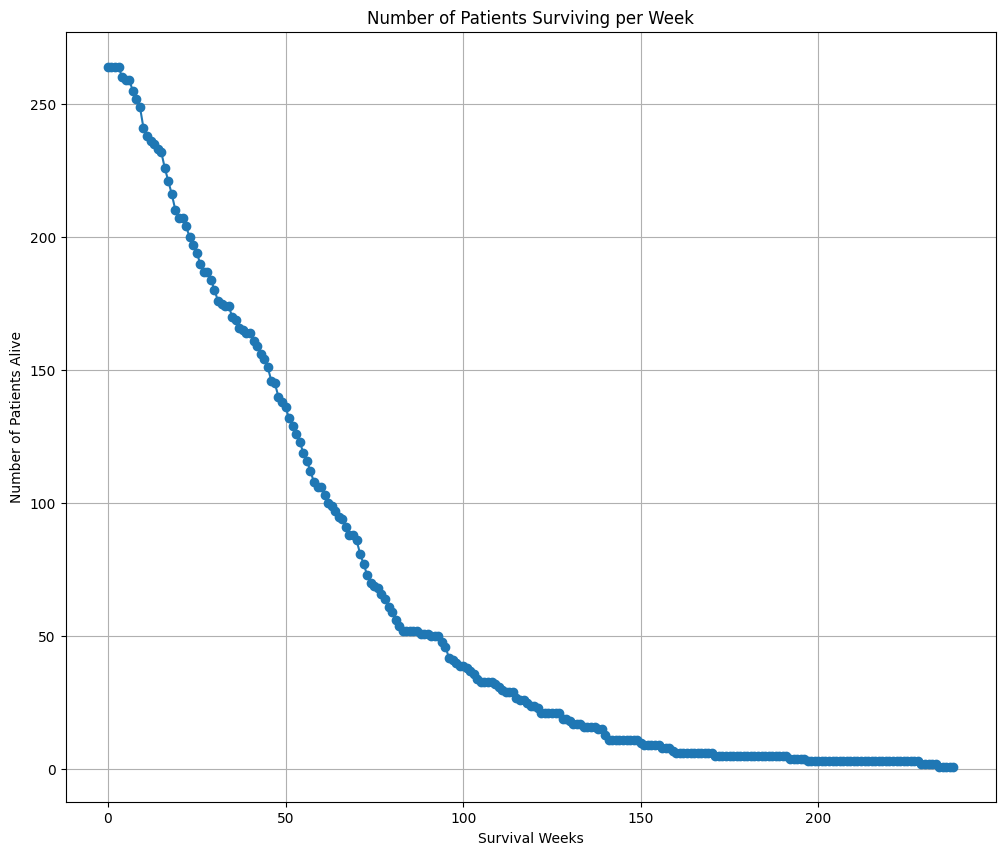

In [6]:
weeks = list(range(0, max_week + 1))
patients_alive = []

for i in weeks:
    alive_count = (df['survival (weeks)'] >= i).sum()
    patients_alive.append(alive_count)

# Step 5: Plot the survival curve
plt.figure(figsize=(12,10))
plt.plot(weeks, patients_alive, marker='o')
plt.title('Number of Patients Surviving per Week')
plt.xlabel('Survival Weeks')
plt.ylabel('Number of Patients Alive')
plt.grid(True)
plt.show()

In [7]:
survival_table = pd.DataFrame({
    'Week': weeks,
    'Patients_Alive': patients_alive
})

survival_table.to_csv('weekly_survival_table.csv', index=False)
survival_table

,Week,Patients_Alive
0,0,264
1,1,264
2,2,264
3,3,264
4,4,260
...,...,...
234,234,1
235,235,1
236,236,1
237,237,1


In [8]:
# Total patients at week 0
total_patients = survival_table['Patients_Alive'].iloc[0]

# Add a new column: Survival Probability
survival_table['Survival_Probability'] = survival_table['Patients_Alive'] / total_patients

# Show first few rows
survival_table

,Week,Patients_Alive,Survival_Probability
0,0,264,1.000000
1,1,264,1.000000
2,2,264,1.000000
3,3,264,1.000000
4,4,260,0.984848
...,...,...,...
234,234,1,0.003788
235,235,1,0.003788
236,236,1,0.003788
237,237,1,0.003788


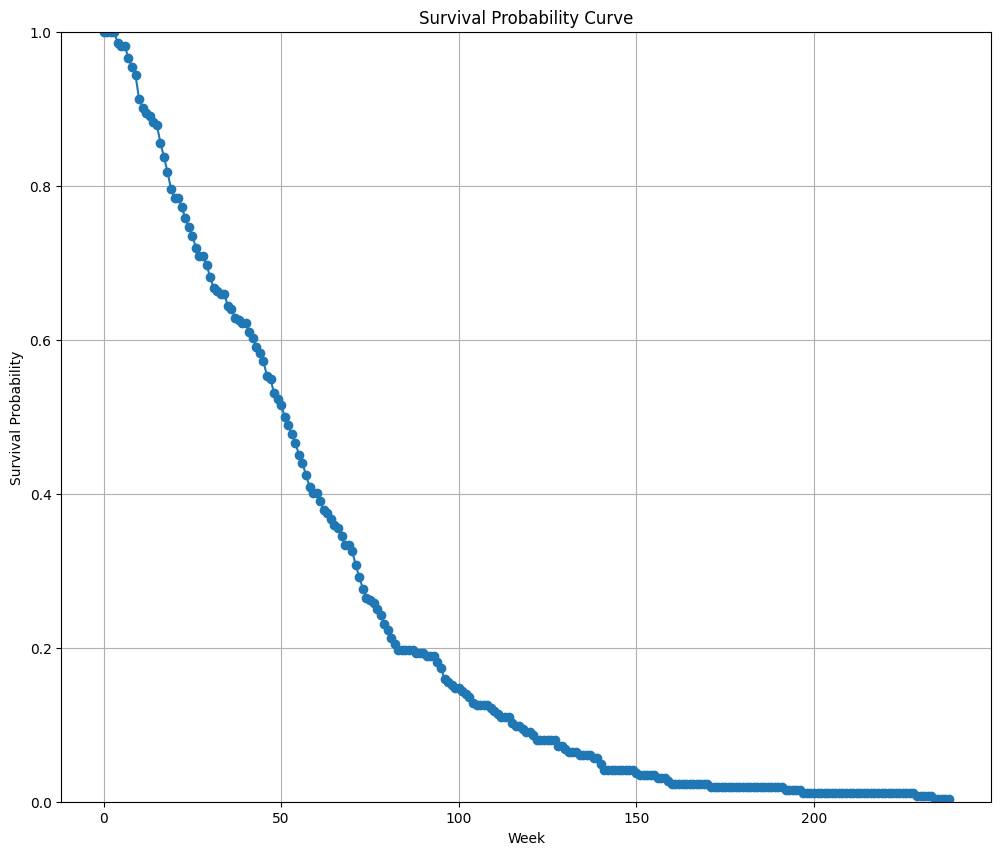

In [11]:
plt.figure(figsize=(12,10))
plt.plot(survival_table['Week'], survival_table['Survival_Probability'], marker='o')
plt.title('Survival Probability Curve')
plt.xlabel('Week')
plt.ylabel('Survival Probability')
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [12]:
survival_table['Weekly_Deaths'] = survival_table['Patients_Alive'].diff(-1).fillna(0)
#survival_table['Weekly_Deaths'] = survival_table['Weekly_Deaths'].astype(int)
survival_table

,Week,Patients_Alive,Survival_Probability,Weekly_Deaths
0,0,264,1.000000,0.0
1,1,264,1.000000,0.0
2,2,264,1.000000,0.0
3,3,264,1.000000,4.0
4,4,260,0.984848,1.0
...,...,...,...,...
234,234,1,0.003788,0.0
235,235,1,0.003788,0.0
236,236,1,0.003788,0.0
237,237,1,0.003788,0.0


In [13]:
male_patients_df = df[df['gender']=='M']
female_patients_df = df[df['gender']=='F']

# Calculate survival counts for males
male_alive_counts = []
for i in weeks:
    alive_male_count = (male_patients_df['survival (weeks)'] >= i).sum()
    male_alive_counts.append(alive_male_count)

# Calculate survival counts for females
female_alive_counts = []
for i in weeks:
    alive_female_count = (female_patients_df['survival (weeks)'] >= i).sum()
    female_alive_counts.append(alive_female_count)

# Add these new counts to the survival_table
survival_table['Males_Alive'] = male_alive_counts
survival_table['Females_Alive'] = female_alive_counts

# Calculate total male and female patients at week 0 for probability calculation
total_males_at_start = survival_table['Males_Alive'].iloc[0]
total_females_at_start = survival_table['Females_Alive'].iloc[0]

# Add new columns for survival probability by gender
survival_table['Survival_Probability_Male'] = survival_table['Males_Alive'] / total_males_at_start
survival_table['Survival_Probability_Female'] = survival_table['Females_Alive'] / total_females_at_start

# Show first few rows
survival_table

,Week,Patients_Alive,Survival_Probability,Weekly_Deaths,Males_Alive,Females_Alive,Survival_Probability_Male,Survival_Probability_Female
0,0,264,1.000000,0.0,158,106,1.000000,1.000000
1,1,264,1.000000,0.0,158,106,1.000000,1.000000
2,2,264,1.000000,0.0,158,106,1.000000,1.000000
3,3,264,1.000000,4.0,158,106,1.000000,1.000000
4,4,260,0.984848,1.0,155,105,0.981013,0.990566
...,...,...,...,...,...,...,...,...
234,234,1,0.003788,0.0,0,1,0.000000,0.009434
235,235,1,0.003788,0.0,0,1,0.000000,0.009434
236,236,1,0.003788,0.0,0,1,0.000000,0.009434
237,237,1,0.003788,0.0,0,1,0.000000,0.009434


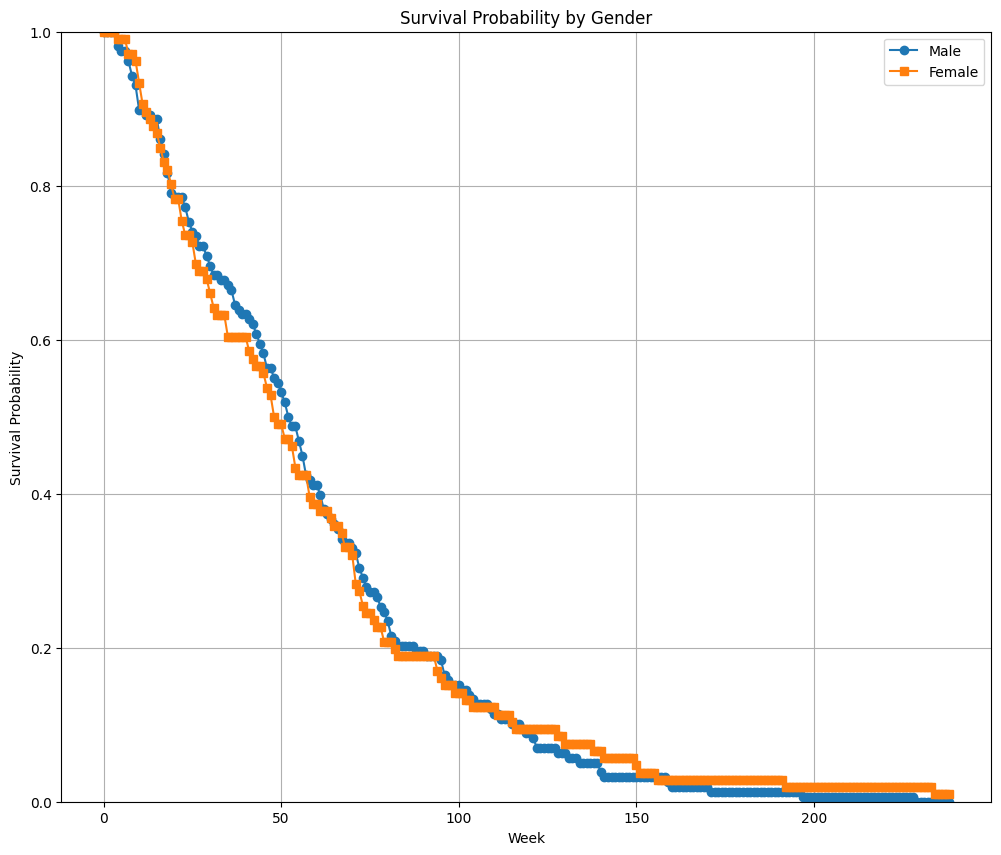

In [17]:
# Plot male survival probability
plt.figure(figsize=(12,10))
plt.plot(survival_table['Week'], survival_table['Survival_Probability_Male'], marker='o', label='Male')

# Plot female survival probability
plt.plot(survival_table['Week'], survival_table['Survival_Probability_Female'], marker='s', label='Female')

# Labels and
plt.title('Survival Probability by Gender')
plt.xlabel('Week')
plt.ylabel('Survival Probability')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=329e011ee7b099e142f50a842d7ed50abd835aa9edba81f2927f484049f12eb2
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


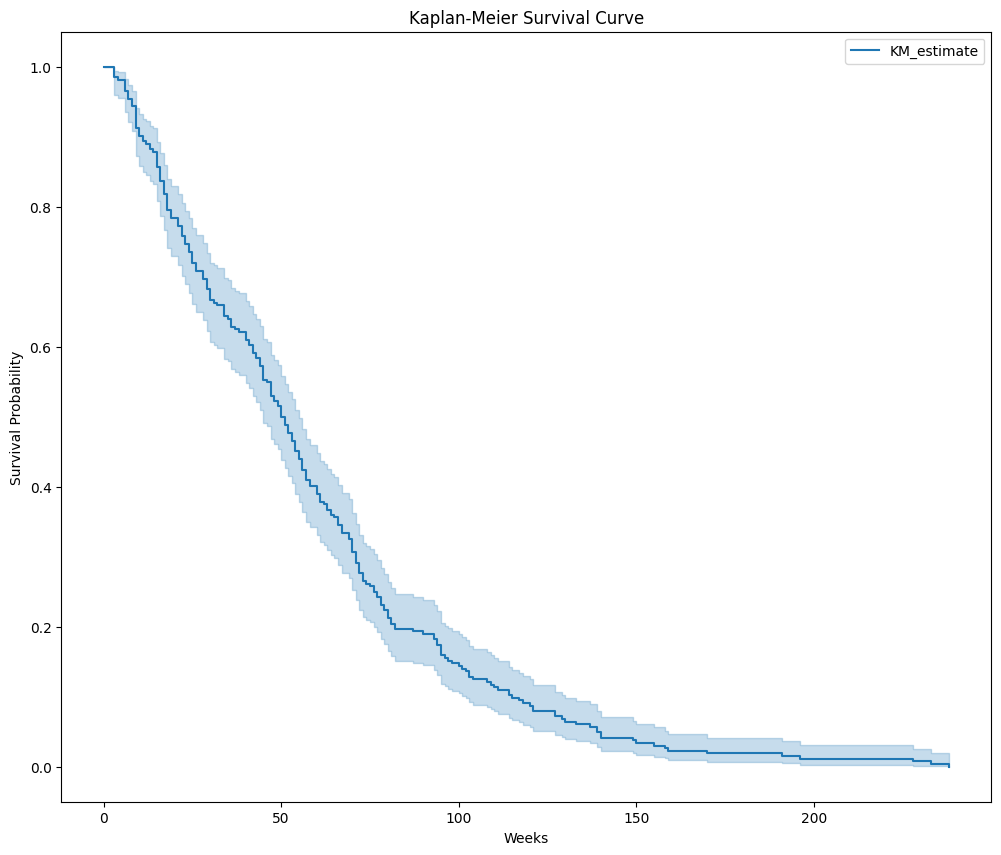

In [26]:
from lifelines import KaplanMeierFitter

# survival_weeks = survival time
# event = 1 (death occurred), 0 (censored)

# Kaplan-Meier Model
kmf = KaplanMeierFitter()

# Create an 'event' column, assuming all patients are observed for the event (death)
df['event'] = 1

kmf.fit(
    durations=df["survival (weeks)"], # Corrected column name
    event_observed=df["event"]
)
plt.figure(figsize=(12,10))

kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Weeks")
plt.ylabel("Survival Probability")
plt.show()

          removed  observed  censored  entrance  at_risk
event_at                                                
0.0             0         0         0       264      264
3.0             4         4         0         0      264
4.0             1         1         0         0      260
6.0             4         4         0         0      259
7.0             3         3         0         0      255


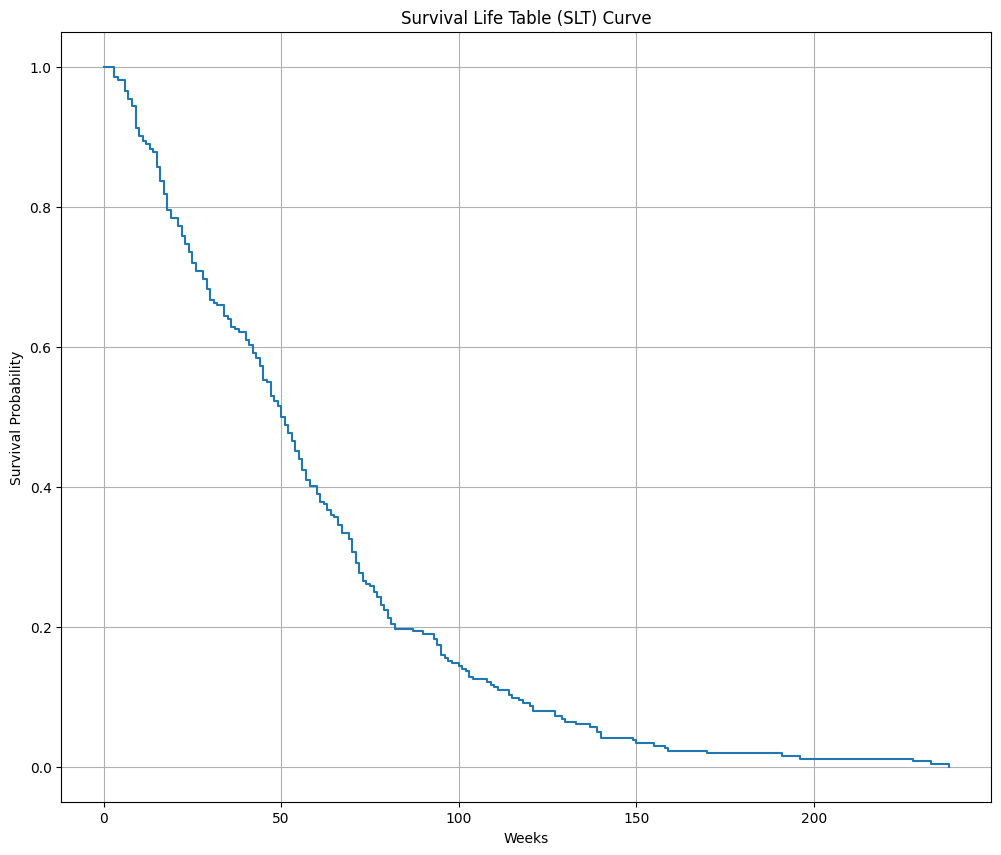

In [27]:
# Access the life-table style event table from the fitted model
slt_table = kmf.event_table

print(slt_table.head())

# Calculate interval survival probability
slt_table["interval_survival"] = 1 - (slt_table["observed"] / slt_table["at_risk"])

# Cumulative survival probability
slt_table["cum_survival"] = slt_table["interval_survival"].cumprod()

# Plot SLT curve
plt.figure(figsize=(12,10))

plt.step(slt_table.index, slt_table["cum_survival"], where="post")

plt.title("Survival Life Table (SLT) Curve")
plt.xlabel("Weeks")
plt.ylabel("Survival Probability")

plt.grid(True)
plt.show()

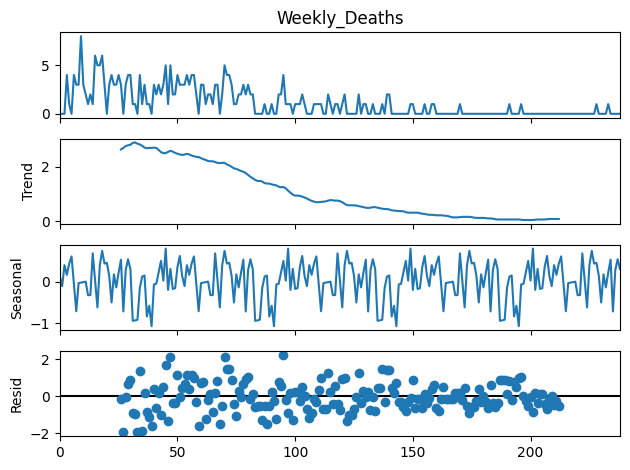

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Apply seasonal decomposition
# Using 'Weekly_Deaths' from the survival_table as the time series
result = seasonal_decompose(survival_table['Weekly_Deaths'], model='additive', period=52)

# Plot the decomposition
result.plot()
plt.show()

In [ ]:

# Import required class
from lifelines import CoxPHFitter

# Prepare dataset
# Rename columns to match expected names for the Cox model
df = df.rename(columns={
    'survival (weeks)': 'Survival_Week',
    'age_at_t0 (years)': 'Age',
    'who_performance_status': 'Performance',
    'delay_t0_to_radiotherapy (weeks)' : 'Radiotherapy Delay',
    'dose (Gy)' : 'Dose',
    'fractions_number' : 'Fractions'
})

# Calculate BMI: BMI = weight (kg) / (height (m))^2
df['BMI'] = df['weight (kg)'] / ((df['height (cm)'] / 100)**2)

# Event column: 1 means the patient died (all patients eventually die here)
df['Event'] = 1

# Convert Gender to numeric for Cox model (Male=0, Female=1)
df['Gender_num'] = df['gender'].map({'M':0, 'F':1})

# Drop rows with NaN in any of the required columns for the Cox model
df_cox = df[['Survival_Week','Event','Gender_num','Age','BMI','Performance','Radiotherapy Delay','Dose','Fractions']].dropna()

# Fit Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Survival_Week', event_col='Event')

# Show model summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 194 total observations, 0 right-censored observations>
             duration col = 'Survival_Week'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 194
number of events observed = 194
   partial log-likelihood = -810.19
         time fit was run = 2026-03-09 07:13:15 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Gender_num         -0.01      0.99      0.15           -0.30            0.29                0.74                1.34
Age                 0.01      1.01      0.01           -0.01            0.03                0.99                1.03
BMI                -0.03      0.97      0.02           -0.06            0.01                0.94                1.01
Performance         0.32      1.38      0.11            0.12            0.53                1.12                1.70
Radiotherapy Delay -0.26      0.77      0.10           -0.46           -0.06                0.63                0.94
Dose               -0.06      0.94      0.07           -0.21            0.08                0.81                1.09
Fractions           0.04      1.04      0.10           -0.15            0.23                0.86                1.26

                    cmp to     z      p  -log2(p)
covariate                                        
Gender_num            0.00 -0.04   0.97      0.05
Age                   0.00  0.95   0.34      1.56
BMI                   0.00 -1.54   0.12      3.01
Performance           0.00  3.07 <0.005      8.88
Radiotherapy Delay    0.00 -2.56   0.01      6.56
Dose                  0.00 -0.86   0.39      1.35
Fractions             0.00  0.41   0.68      0.55
---
Concordance = 0.67
Partial AIC = 1634.39
log-likelihood ratio test = 42.65 on 7 df
-log2(p) of ll-ratio test = 21.29

In [ ]:
# Significance level
alpha = 0.05

# Create a summary DataFrame
summary_df = cph.summary.copy()

# Add column for significance
summary_df['Significant'] = summary_df['p'] < alpha

# Optional: add interpretation
summary_df['Interpretation'] = summary_df.apply(
    lambda row: f"{row.name} increases risk" if row['coef']>0 and row['Significant']
    else (f"{row.name} decreases risk" if row['coef']<0 and row['Significant']
          else f"{row.name} not significant"), axis=1
)

summary_df[['coef','exp(coef)','p','Significant','Interpretation']]

,coef,exp(coef),p,Significant,Interpretation
covariate,,,,,
Gender_num,-0.006348,0.993672,0.966442,False,Gender_num not significant
Age,0.008848,1.008887,0.340189,False,Age not significant
BMI,-0.027933,0.972453,0.124365,False,BMI not significant
Performance,0.324958,1.383973,0.002125,True,Performance increases risk
Radiotherapy Delay,-0.262169,0.769381,0.010568,True,Radiotherapy Delay decreases risk
Dose,-0.063852,0.938144,0.392069,False,Dose not significant
Fractions,0.040480,1.041311,0.680944,False,Fractions not significant


In [ ]:

# Import required class
from lifelines import CoxPHFitter

# Prepare dataset
# Rename columns to match expected names for the Cox model
df = df.rename(columns={
    'survival (weeks)': 'Survival_Week',
    'age_at_t0 (years)': 'Age',
    'who_performance_status': 'Performance'
})

# Calculate BMI: BMI = weight (kg) / (height (m))^2
df['BMI'] = df['weight (kg)'] / ((df['height (cm)'] / 100)**2)

# Event column: 1 means the patient died (all patients eventually die here)
df['Event'] = 1

# Convert Gender to numeric for Cox model (Male=0, Female=1)
df['Gender_num'] = df['gender'].map({'M':0, 'F':1})

# Drop rows with NaN in any of the required columns for the Cox model
df_cox = df[['Survival_Week','Event','Gender_num','Age','BMI','Performance']].dropna()

# Fit Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Survival_Week', event_col='Event')

# Show model summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 263 total observations, 0 right-censored observations>
             duration col = 'Survival_Week'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 263
number of events observed = 263
   partial log-likelihood = -1193.18
         time fit was run = 2026-03-08 20:17:28 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Gender_num  -0.04      0.96      0.13           -0.29            0.21                0.75                1.23
Age          0.03      1.03      0.01            0.02            0.04                1.02                1.04
BMI         -0.01      0.99      0.01           -0.04            0.02                0.97                1.02
Performance  0.17      1.19      0.09            0.00            0.34                1.00                1.40

             cmp to     z      p  -log2(p)
covariate                                 
Gender_num     0.00 -0.32   0.75      0.41
Age            0.00  4.42 <0.005     16.62
BMI            0.00 -0.50   0.62      0.69
Performance    0.00  1.98   0.05      4.37
---
Concordance = 0.63
Partial AIC = 2394.37
log-likelihood ratio test = 25.99 on 4 df
-log2(p) of ll-ratio test = 14.94

In [ ]:
# Significance level
alpha = 0.05

# Create a summary DataFrame
summary_df = cph.summary.copy()

# Add column for significance
summary_df['Significant'] = summary_df['p'] < alpha

# Optional: add interpretation
summary_df['Interpretation'] = summary_df.apply(
    lambda row: f"{row.name} increases risk" if row['coef']>0 and row['Significant']
    else (f"{row.name} decreases risk" if row['coef']<0 and row['Significant']
          else f"{row.name} not significant"), axis=1
)

summary_df[['coef','exp(coef)','p','Significant','Interpretation']]

,coef,exp(coef),p,Significant,Interpretation
covariate,,,,,
Gender_num,-0.040159,0.960636,0.752193,False,Gender_num not significant
Age,0.029393,1.029829,0.000010,True,Age increases risk
BMI,-0.007126,0.992899,0.618591,False,BMI not significant
Performance,0.170228,1.185575,0.048231,True,Performance increases risk


In [ ]:
# Use actual unique values from your dataset
genders = df['Gender_num'].unique()  # 0 and 1
performances = df['Performance'].unique()  # 0 to 3
ages = sorted(df['Age'].unique())  # all ages in dataset
bmis = sorted(df['BMI'].round(1).unique())  # rounded BMI for clarity

# Generate all realistic patient profiles
import itertools
all_combinations = list(itertools.product(genders, performances, ages, bmis))
patient_profiles = pd.DataFrame(all_combinations, columns=['Gender_num','Performance','Age','BMI'])

# Add label for plotting
def label_row(row):
    gender = 'M' if row['Gender_num']==0 else 'F'
    return f"{gender} Perf{row['Performance']} Age{row['Age']} BMI{row['BMI']}"

patient_profiles['Label'] = patient_profiles.apply(label_row, axis=1)

print(f"Total realistic patient profiles: {len(patient_profiles)}")

Total realistic patient profiles: 17500


In [ ]:
# Predict partial hazard (relative hazard) for each patient profile
patient_profiles['Predicted_Hazard'] = cph.predict_partial_hazard(patient_profiles[['Gender_num','Performance','Age','BMI']])

In [ ]:
patient_profiles = patient_profiles.sort_values(by='Predicted_Hazard', ascending=False)

In [ ]:
import itertools

# Define ranges
genders = [0, 1]  # 0=Male, 1=Female
performances = [0,1,2,3]
ages = [40,50,60]
bmis = [22,25,28]

# Generate all combinations
all_combinations = list(itertools.product(genders, performances, ages, bmis))

# Create DataFrame
patient_profiles = pd.DataFrame(all_combinations, columns=['Gender_num','Performance','Age','BMI'])

# Add label for plotting
def label_row(row):
    gender = 'M' if row['Gender_num']==0 else 'F'
    return f"{gender} Perf{row['Performance']} Age{row['Age']} BMI{row['BMI']}"

patient_profiles['Label'] = patient_profiles.apply(label_row, axis=1)

print(f"Total patient profiles: {len(patient_profiles)}")  # Should be 2*4*3*3 = 72

Total patient profiles: 72


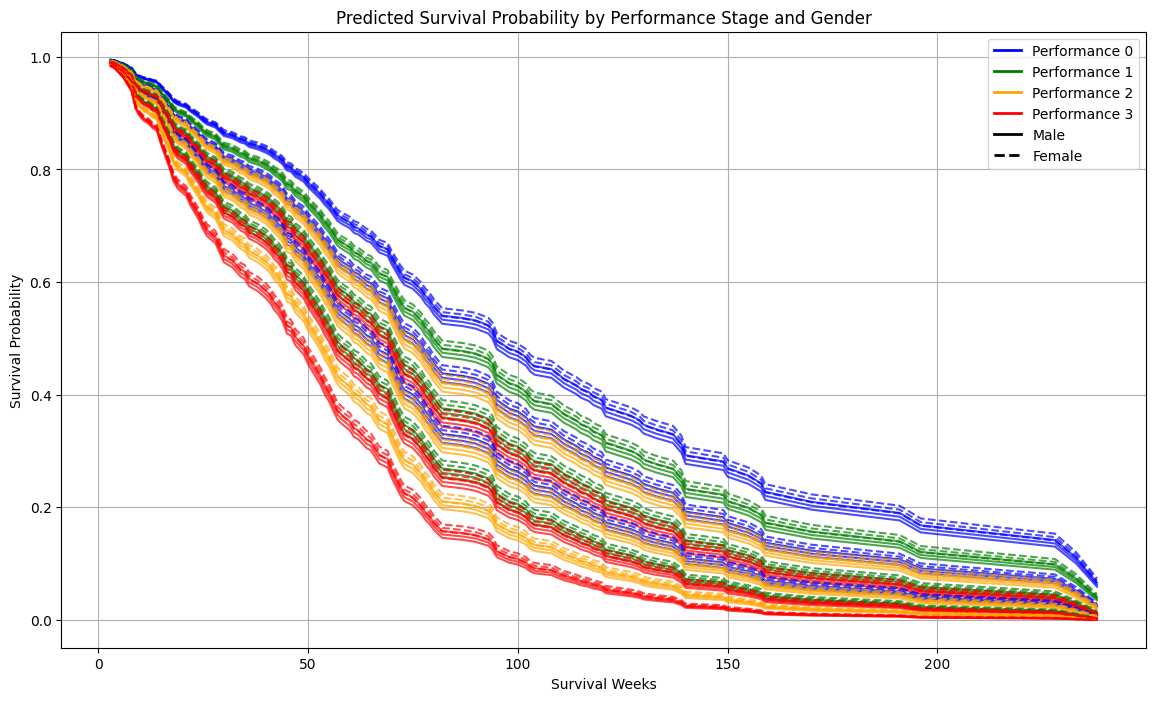

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14,8))

# Define colors for Performance stage
performance_colors = {0:'blue', 1:'green', 2:'orange', 3:'red'}

# Define line style for Gender
gender_styles = {0:'-', 1:'--'}  # Male solid, Female dashed

# Plot survival curves
for i in range(len(patient_profiles)):
    row = patient_profiles.iloc[i:i+1]
    survival_func = cph.predict_survival_function(row)

    perf = row['Performance'].values[0]
    gender = row['Gender_num'].values[0]

    plt.plot(
        survival_func.index,
        survival_func.values.flatten(),
        color=performance_colors[perf],
        linestyle=gender_styles[gender],
        alpha=0.7
    )

# Create legend for Performance
from matplotlib.lines import Line2D
legend_perf = [Line2D([0], [0], color=c, lw=2, label=f'Performance {p}')
               for p,c in performance_colors.items()]
# Legend for Gender
legend_gender = [Line2D([0], [0], color='black', lw=2, linestyle=s, label=g)
                 for g,s in zip(['Male','Female'], ['-', '--'])]

plt.legend(handles=legend_perf + legend_gender, loc='upper right')
plt.title('Predicted Survival Probability by Performance Stage and Gender')
plt.xlabel('Survival Weeks')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

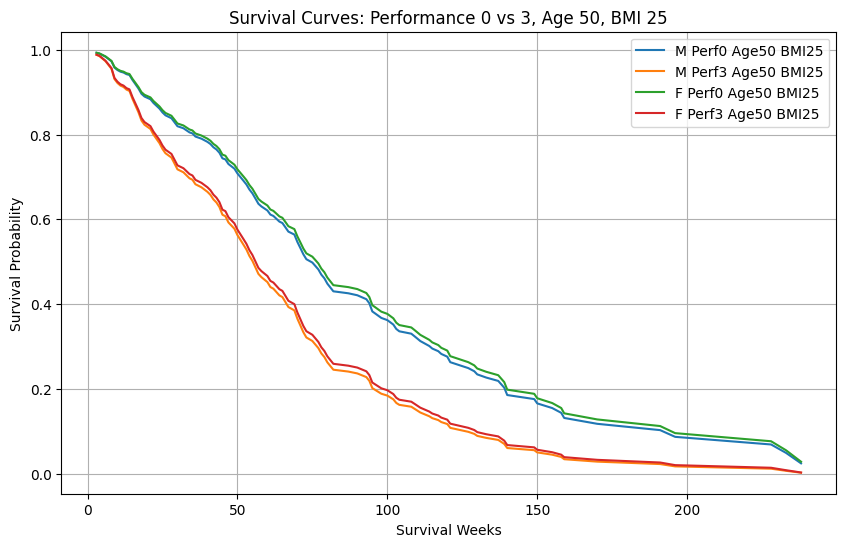

In [ ]:
# Example: only Performance 0 & 3 and Age=50, BMI=25
filtered_profiles = patient_profiles[
    ((patient_profiles['Performance']==0) | (patient_profiles['Performance']==3)) &
    (patient_profiles['Age']==50) &
    (patient_profiles['BMI']==25)
]

plt.figure(figsize=(10,6))
for i in range(len(filtered_profiles)):
    sf = cph.predict_survival_function(filtered_profiles.iloc[i:i+1])
    plt.plot(sf.index, sf.values.flatten(), label=filtered_profiles['Label'].iloc[i])

plt.title('Survival Curves: Performance 0 vs 3, Age 50, BMI 25')
plt.xlabel('Survival Weeks')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()